In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully")

Libraries imported successfully


In [15]:
DATA_PATH = Path("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(f"Путь к датасету: {DATA_PATH.resolve()}")
print(f"Файл существует: {DATA_PATH.exists()}")

df = pd.read_csv(DATA_PATH)

print(f"Размер датасета: {df.shape}")

df.head()

Путь к датасету: C:\Users\AlimzhanKasenov\PycharmProjects\ml-pro-homeworks\hw01_boosting\data\WA_Fn-UseC_-Telco-Customer-Churn.csv
Файл существует: True
Размер датасета: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
print("Размер датасета:")
print(df.shape)

print("\nНазвания колонок:")
print(df.columns.tolist())

print("\nТипы данных:")
print(df.dtypes)

Размер датасета:
(7043, 21)

Названия колонок:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Типы данных:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [17]:
print("Количество пропусков:")
print(df.isnull().sum())

print("\nКоличество полных дубликатов:")
print(df.duplicated().sum())

Количество пропусков:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Количество полных дубликатов:
0


In [18]:
print("Распределение целевой переменной Churn:")
print(df["Churn"].value_counts())

print("\nРаспределение в процентах:")
print(df["Churn"].value_counts(normalize=True) * 100)

Распределение целевой переменной Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Распределение в процентах:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [19]:
print("Тип TotalCharges:")
print(df["TotalCharges"].dtype)

print("\nКоличество пустых строк в TotalCharges:")
print((df["TotalCharges"].astype(str).str.strip() == "").sum())

Тип TotalCharges:
str

Количество пустых строк в TotalCharges:
11


In [20]:
df_eda = df.copy()

df_eda["TotalCharges"] = pd.to_numeric(
    df_eda["TotalCharges"].str.strip(),
    errors="coerce"
)

print("Тип TotalCharges после преобразования:")
print(df_eda["TotalCharges"].dtype)

print("\nКоличество пропусков после преобразования:")
print(df_eda["TotalCharges"].isna().sum())

Тип TotalCharges после преобразования:
float64

Количество пропусков после преобразования:
11


In [21]:
numeric_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

df_eda[numeric_columns].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


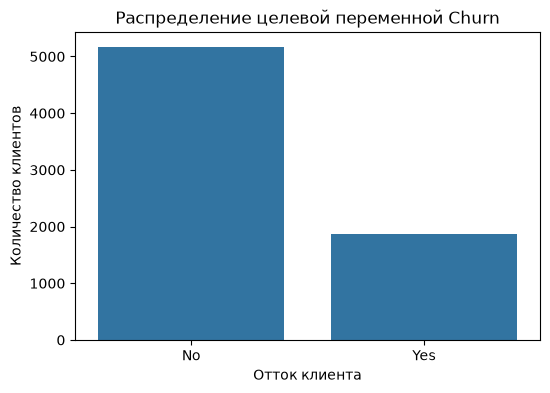

In [22]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_eda,
    x="Churn"
)

plt.title("Распределение целевой переменной Churn")
plt.xlabel("Отток клиента")
plt.ylabel("Количество клиентов")

plt.show()

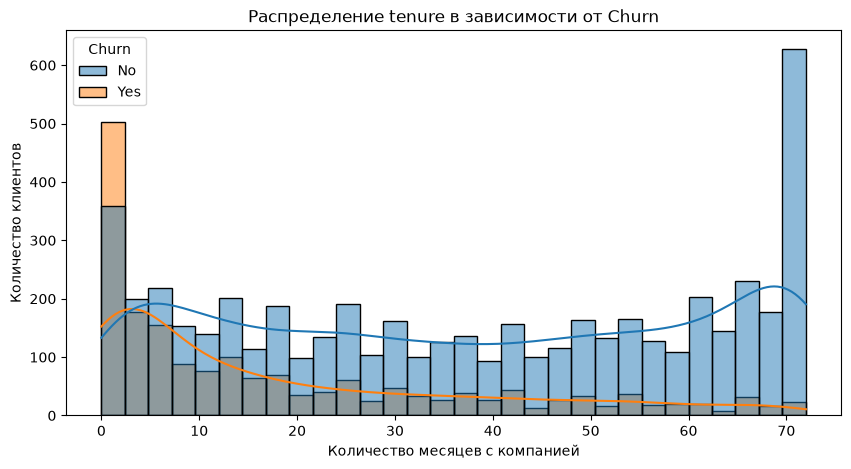

In [23]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_eda,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Распределение tenure в зависимости от Churn")
plt.xlabel("Количество месяцев с компанией")
plt.ylabel("Количество клиентов")

plt.show()

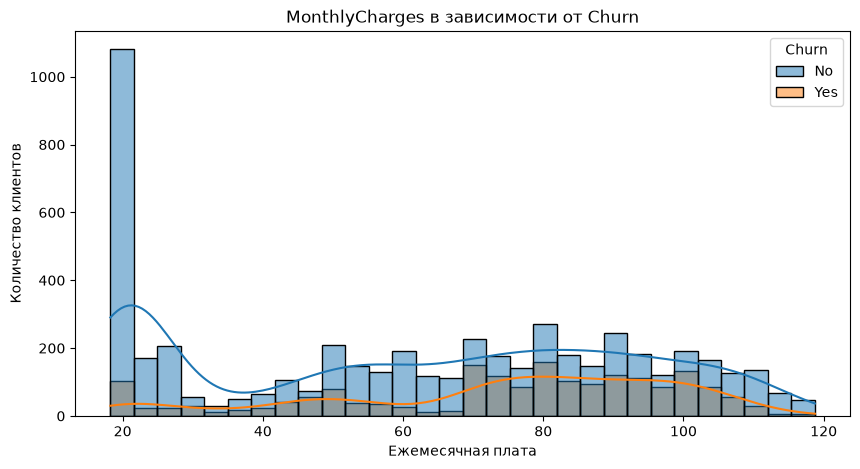

In [24]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_eda,
    x="MonthlyCharges",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("MonthlyCharges в зависимости от Churn")
plt.xlabel("Ежемесячная плата")
plt.ylabel("Количество клиентов")

plt.show()

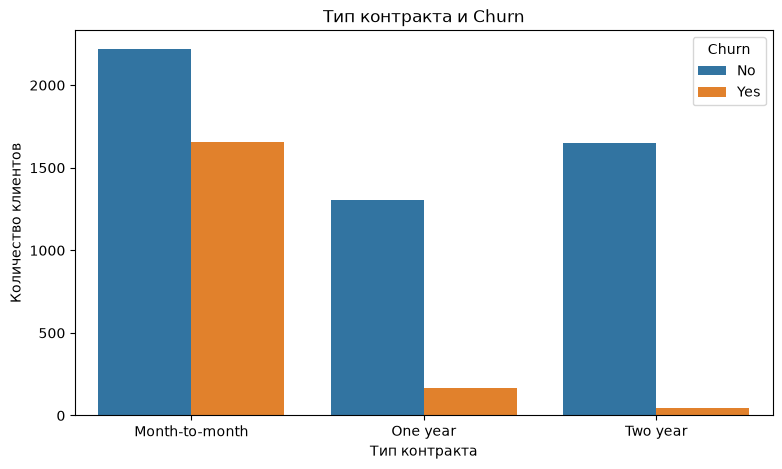

In [25]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_eda,
    x="Contract",
    hue="Churn"
)

plt.title("Тип контракта и Churn")
plt.xlabel("Тип контракта")
plt.ylabel("Количество клиентов")

plt.show()

In [26]:
contract_churn = (
    df_eda
    .groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print("Процент оттока по типу контракта:")
print(contract_churn)

Процент оттока по типу контракта:
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


In [27]:
internet_churn = (
    df_eda
    .groupby("InternetService")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print("Процент оттока по типу интернет-сервиса:")
print(internet_churn)

Процент оттока по типу интернет-сервиса:
InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Churn, dtype: float64


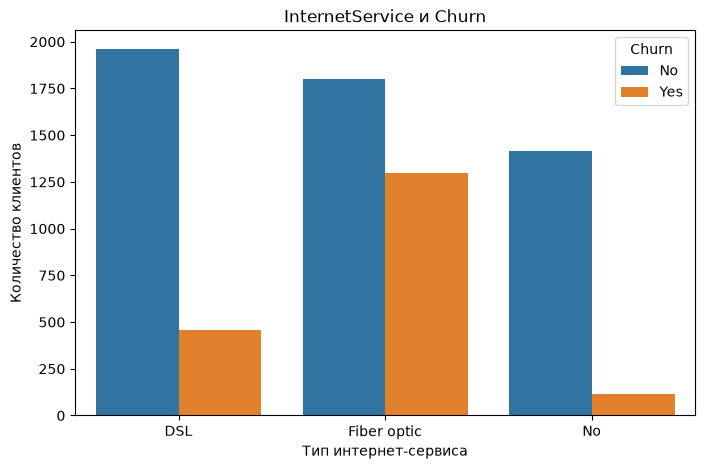

In [28]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_eda,
    x="InternetService",
    hue="Churn"
)

plt.title("InternetService и Churn")
plt.xlabel("Тип интернет-сервиса")
plt.ylabel("Количество клиентов")

plt.show()

In [29]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

df_model = df.copy()

# Преобразуем TotalCharges в числовой формат.
# Пустые строки превратятся в NaN.
df_model["TotalCharges"] = pd.to_numeric(
    df_model["TotalCharges"].str.strip(),
    errors="coerce"
)

print("Пропусков до удаления:")
print(df_model["TotalCharges"].isna().sum())

# В датасете всего 11 таких строк из 7043,
# поэтому их можно удалить без существенной потери данных.
df_model = df_model.dropna(subset=["TotalCharges"]).copy()

print("Размер после удаления пропусков:")
print(df_model.shape)

Пропусков до удаления:
11
Размер после удаления пропусков:
(7032, 21)


In [30]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

df_model = df.copy()

# TotalCharges должен быть числовым признаком.
# Пустые строки преобразуем в NaN.
df_model["TotalCharges"] = pd.to_numeric(
    df_model["TotalCharges"].str.strip(),
    errors="coerce"
)

print("Пропусков в TotalCharges:")
print(df_model["TotalCharges"].isna().sum())

# Таких строк всего 11 из 7043 — удаляем их.
df_model = df_model.dropna(subset=["TotalCharges"]).copy()

print("\nРазмер датасета после удаления пропусков:")
print(df_model.shape)

Пропусков в TotalCharges:
11

Размер датасета после удаления пропусков:
(7032, 21)


In [31]:
# Колонки дополнительных услуг
service_columns = [
    "PhoneService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

# Количество подключённых услуг у клиента
df_model["ServicesCount"] = (
    df_model[service_columns]
    .eq("Yes")
    .sum(axis=1)
)

# Есть ли у клиента семья:
# партнёр или иждивенцы
df_model["HasFamily"] = (
    (df_model["Partner"] == "Yes") |
    (df_model["Dependents"] == "Yes")
).astype(int)

# Клиент пользуется услугами компании не менее двух лет
df_model["LongTermCustomer"] = (
    df_model["tenure"] >= 24
).astype(int)

print(
    df_model[
        [
            "ServicesCount",
            "HasFamily",
            "LongTermCustomer"
        ]
    ].head()
)

   ServicesCount  HasFamily  LongTermCustomer
0              1          1                 0
1              3          0                 1
2              3          0                 0
3              3          0                 1
4              1          0                 0


In [32]:
print("Размер после Feature Engineering:")
print(df_model.shape)

Размер после Feature Engineering:
(7032, 24)


In [33]:
df_model = df_model.drop(columns=["customerID"])

print("Размер после удаления customerID:")
print(df_model.shape)

Размер после удаления customerID:
(7032, 23)


In [34]:
categorical_columns = df_model.select_dtypes(
    include=["object", "str"]
).columns.tolist()

print("Категориальные признаки:")
print(categorical_columns)

print("\nКоличество категориальных признаков:")
print(len(categorical_columns))

Категориальные признаки:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

Количество категориальных признаков:
16


In [35]:
label_encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()

    df_model[column] = encoder.fit_transform(
        df_model[column]
    )

    label_encoders[column] = encoder

print("Категориальные признаки успешно закодированы.")

Категориальные признаки успешно закодированы.


In [36]:
churn_encoder = label_encoders["Churn"]

print("Классы Churn:")
for encoded_value, original_value in enumerate(
    churn_encoder.classes_
):
    print(
        f"{original_value} -> {encoded_value}"
    )

Классы Churn:
No -> 0
Yes -> 1


In [37]:
print("Пропуски:")
print(df_model.isna().sum().sum())

print("\nДубликаты:")
print(df_model.duplicated().sum())

print("\nТипы данных:")
print(df_model.dtypes)

Пропуски:
0

Дубликаты:
22

Типы данных:
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
ServicesCount         int64
HasFamily             int64
LongTermCustomer      int64
dtype: object


In [38]:
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

print("Размер X:")
print(X.shape)

print("\nРазмер y:")
print(y.shape)

Размер X:
(7032, 22)

Размер y:
(7032,)


In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5625, 22)
X_test: (1407, 22)
y_train: (5625,)
y_test: (1407,)


In [40]:
print("Распределение Churn в train:")
print(
    y_train.value_counts(normalize=True) * 100
)

print("\nРаспределение Churn в test:")
print(
    y_test.value_counts(normalize=True) * 100
)

Распределение Churn в train:
Churn
0    73.422222
1    26.577778
Name: proportion, dtype: float64

Распределение Churn в test:
Churn
0    73.418621
1    26.581379
Name: proportion, dtype: float64


In [41]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

In [42]:
models = {
    "GradientBoosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        random_state=42,
        verbose=0
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        verbosity=-1
    )
}

print("Создано моделей:", len(models))

for name in models:
    print(name)

Создано моделей: 4
GradientBoosting
XGBoost
CatBoost
LightGBM


In [43]:
baseline_results = []

for name, model in models.items():

    print(f"Обучение модели: {name}")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    baseline_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc
    })

print("\nОбучение завершено.")

Обучение модели: GradientBoosting
Обучение модели: XGBoost
Обучение модели: CatBoost
Обучение модели: LightGBM

Обучение завершено.


In [44]:
baseline_df = pd.DataFrame(baseline_results)

baseline_df = baseline_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

baseline_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,GradientBoosting,0.798152,0.646104,0.532086,0.583578,0.838669
1,LightGBM,0.783227,0.606154,0.526738,0.563662,0.827100
2,CatBoost,0.787491,0.620579,0.516043,0.563504,0.826009
3,XGBoost,0.772566,0.578488,0.532086,0.554318,0.806675


In [45]:
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross-validation готова.")

Cross-validation готова.


In [46]:
tuning_models = {
    "GradientBoosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        n_jobs=1
    ),

    "CatBoost": CatBoostClassifier(
        random_state=42,
        verbose=0,
        allow_writing_files=False,
        thread_count=1
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        verbosity=-1,
        n_jobs=1,
        subsample_freq=1
    )
}

In [47]:
param_distributions = {
    "GradientBoosting": {
        "n_estimators": [50, 100, 150, 200, 300],
        "learning_rate": [0.03, 0.05, 0.1, 0.15],
        "max_depth": [2, 3, 4, 5],
        "subsample": [0.7, 0.85, 1.0],
        "max_features": [None, "sqrt", "log2"]
    },

    "XGBoost": {
        "n_estimators": [100, 200, 300, 500],
        "learning_rate": [0.03, 0.05, 0.1, 0.15],
        "max_depth": [3, 4, 5, 6],
        "subsample": [0.7, 0.85, 1.0],
        "colsample_bytree": [0.7, 0.85, 1.0]
    },

    "CatBoost": {
        "iterations": [200, 300, 500, 700],
        "learning_rate": [0.03, 0.05, 0.1],
        "depth": [4, 6, 8],
        "l2_leaf_reg": [1, 3, 5, 7, 10]
    },

    "LightGBM": {
        "n_estimators": [100, 200, 300, 500],
        "learning_rate": [0.03, 0.05, 0.1, 0.15],
        "max_depth": [-1, 3, 5, 7],
        "num_leaves": [15, 31, 63],
        "subsample": [0.7, 0.85, 1.0],
        "colsample_bytree": [0.7, 0.85, 1.0]
    }
}

In [48]:
best_models = {}
cv_results = []

for name, model in tuning_models.items():

    print("=" * 60)
    print(f"Подбор гиперпараметров: {name}")

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions[name],
        n_iter=12,
        scoring="roc_auc",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    search.fit(X_train, y_train)

    best_models[name] = search.best_estimator_

    cv_results.append({
        "Model": name,
        "Best CV ROC-AUC": search.best_score_,
        "Best Parameters": search.best_params_
    })

    print(f"\nЛучший CV ROC-AUC: {search.best_score_:.4f}")
    print("Лучшие параметры:")
    print(search.best_params_)

Подбор гиперпараметров: GradientBoosting
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Лучший CV ROC-AUC: 0.8498
Лучшие параметры:
{'subsample': 0.85, 'n_estimators': 150, 'max_features': 'sqrt', 'max_depth': 4, 'learning_rate': 0.05}
Подбор гиперпараметров: XGBoost
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Лучший CV ROC-AUC: 0.8495
Лучшие параметры:
{'subsample': 0.85, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 1.0}
Подбор гиперпараметров: CatBoost
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Лучший CV ROC-AUC: 0.8500
Лучшие параметры:
{'learning_rate': 0.03, 'l2_leaf_reg': 7, 'iterations': 300, 'depth': 4}
Подбор гиперпараметров: LightGBM
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Лучший CV ROC-AUC: 0.8457
Лучшие параметры:
{'subsample': 0.85, 'num_leaves': 31, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.03, 'colsample_bytree': 0.7}


In [49]:
cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="Best CV ROC-AUC",
    ascending=False
).reset_index(drop=True)

cv_results_df

,Model,Best CV ROC-AUC,Best Parameters
0,CatBoost,0.850034,"{'learning_rate': 0.03, 'l2_leaf_reg': 7, 'ite..."
1,GradientBoosting,0.849774,"{'subsample': 0.85, 'n_estimators': 150, 'max_..."
2,XGBoost,0.849487,"{'subsample': 0.85, 'n_estimators': 200, 'max_..."
3,LightGBM,0.845661,"{'subsample': 0.85, 'num_leaves': 31, 'n_estim..."


In [50]:
tuned_results = []

for name, model in best_models.items():

    print(f"Проверка настроенной модели: {name}")

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc
    })

print("\nПроверка настроенных моделей завершена.")

Проверка настроенной модели: GradientBoosting
Проверка настроенной модели: XGBoost
Проверка настроенной модели: CatBoost
Проверка настроенной модели: LightGBM

Проверка настроенных моделей завершена.


In [51]:
tuned_df = pd.DataFrame(tuned_results)

tuned_df = tuned_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

tuned_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,0.793177,0.636964,0.516043,0.570162,0.838291
1,CatBoost,0.795309,0.644295,0.513369,0.571429,0.838057
2,GradientBoosting,0.792466,0.633987,0.518717,0.570588,0.836454
3,LightGBM,0.792466,0.628931,0.534759,0.578035,0.835022


In [52]:
tuned_display = tuned_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]

tuned_display[metric_columns] = (
    tuned_display[metric_columns]
    .round(4)
)

tuned_display

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,0.7932,0.6370,0.5160,0.5702,0.8383
1,CatBoost,0.7953,0.6443,0.5134,0.5714,0.8381
2,GradientBoosting,0.7925,0.6340,0.5187,0.5706,0.8365
3,LightGBM,0.7925,0.6289,0.5348,0.5780,0.8350


In [53]:
comparison_df = baseline_df.merge(
    tuned_df,
    on="Model",
    suffixes=("_Baseline", "_Tuned")
)

comparison_df["ROC-AUC Improvement"] = (
    comparison_df["ROC-AUC_Tuned"]
    - comparison_df["ROC-AUC_Baseline"]
)

comparison_df = comparison_df[
    [
        "Model",
        "ROC-AUC_Baseline",
        "ROC-AUC_Tuned",
        "ROC-AUC Improvement",
        "F1_Baseline",
        "F1_Tuned",
        "Recall_Baseline",
        "Recall_Tuned"
    ]
]

comparison_df = comparison_df.sort_values(
    by="ROC-AUC_Tuned",
    ascending=False
).reset_index(drop=True)

comparison_df.round(4)

,Model,ROC-AUC_Baseline,ROC-AUC_Tuned,ROC-AUC Improvement,F1_Baseline,F1_Tuned,Recall_Baseline,Recall_Tuned
0,XGBoost,0.8067,0.8383,0.0316,0.5543,0.5702,0.5321,0.5160
1,CatBoost,0.8260,0.8381,0.0120,0.5635,0.5714,0.5160,0.5134
2,GradientBoosting,0.8387,0.8365,-0.0022,0.5836,0.5706,0.5321,0.5187
3,LightGBM,0.8271,0.8350,0.0079,0.5637,0.5780,0.5267,0.5348


In [54]:
best_tuned_model = tuned_df.iloc[0]

print("Итоговый победитель:")
print(best_tuned_model["Model"])

print(
    f"ROC-AUC на test: "
    f"{best_tuned_model['ROC-AUC']:.4f}"
)

print(
    f"F1 на test: "
    f"{best_tuned_model['F1']:.4f}"
)

print(
    f"Recall на test: "
    f"{best_tuned_model['Recall']:.4f}"
)

Итоговый победитель:
XGBoost
ROC-AUC на test: 0.8383
F1 на test: 0.5702
Recall на test: 0.5160


In [55]:
for name, model in best_models.items():
    print("=" * 60)
    print(name)
    print()

    row = cv_results_df[
        cv_results_df["Model"] == name
    ].iloc[0]

    print("Best CV ROC-AUC:")
    print(round(row["Best CV ROC-AUC"], 6))

    print("\nЛучшие параметры:")
    print(row["Best Parameters"])

    print()


GradientBoosting

Best CV ROC-AUC:
0.849774

Лучшие параметры:
{'subsample': 0.85, 'n_estimators': 150, 'max_features': 'sqrt', 'max_depth': 4, 'learning_rate': 0.05}

XGBoost

Best CV ROC-AUC:
0.849487

Лучшие параметры:
{'subsample': 0.85, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 1.0}

CatBoost

Best CV ROC-AUC:
0.850034

Лучшие параметры:
{'learning_rate': 0.03, 'l2_leaf_reg': 7, 'iterations': 300, 'depth': 4}

LightGBM

Best CV ROC-AUC:
0.845661

Лучшие параметры:
{'subsample': 0.85, 'num_leaves': 31, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.03, 'colsample_bytree': 0.7}

